In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# 数据变换方式

数据变换主要是对数据进行规范化处理，将数据从一种表现形式变为另一种表现形式的过程。

在数据预处理中，我们需要先对字段进行筛选，然后对数据进行探索和相关性分析，接着是选择算法模型，继而针对算法模型对数据的需求进行数据变换，从而完成数据的准备工作。  
从整个流程中可以看出，数据变换是数据准备的重要环节，它通过数据平滑、数据聚集、数据概化、数据规范化等方式将数据转化成适用于数据挖掘的形式。

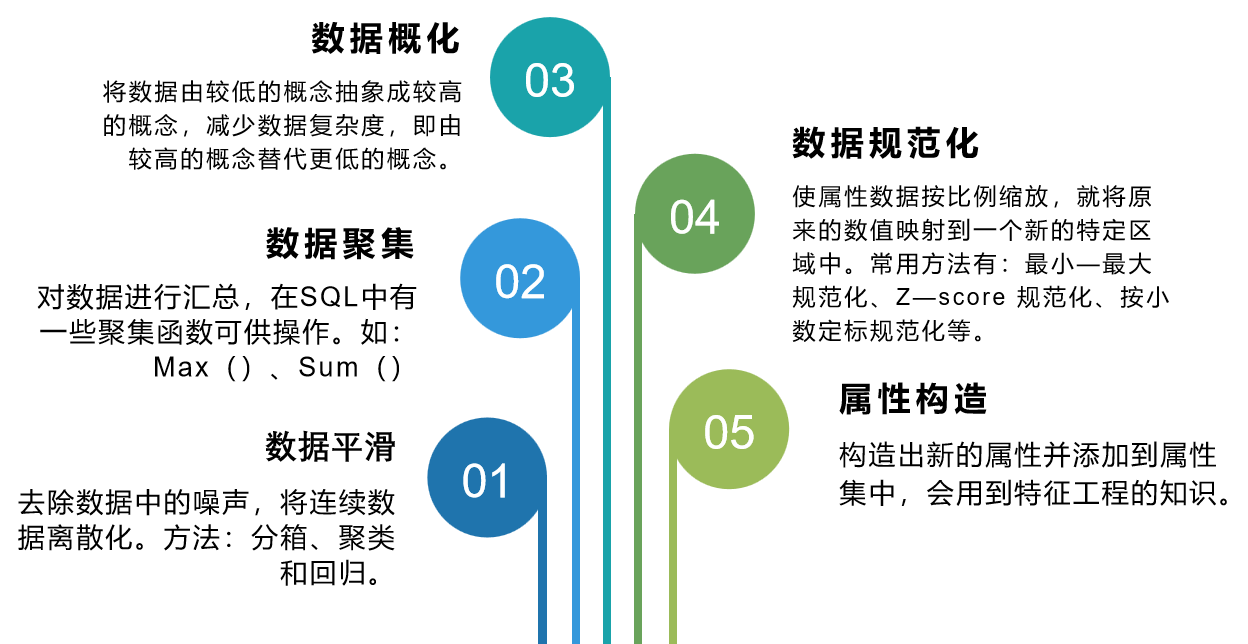

# 常见操作
数据变换的常见操作是数据的处理，例如，对原始数据进行数学函数变换、规范化、小波变换、属性构造和属性离散化操作，目的是使数据更适合应用。

## 简单函数变换
1.简单函数变换是对原始数据进行某些数学函数变换，常用的变换包括平方（使用 **运算符或 pow()方法）、开方（使用 np.sqrt()或 ** 0.5）、取对数（使用 np.log()、np.log10()、np.log2()等）、差分运算等（使用 diff()方法）。    
2.连续特征变换，常用方法有3种:基于多项式的数据变换、基于指数函数的数据变换和基于对数函数的数据变换。

## 连续属性离散化
数据离散化是指将连续的数据进行分段，使其变为一段段离散化的区间。  
离散化涉及两个子任务：确定分类数及将连续属性值映射到分类值。

离散化常用方法
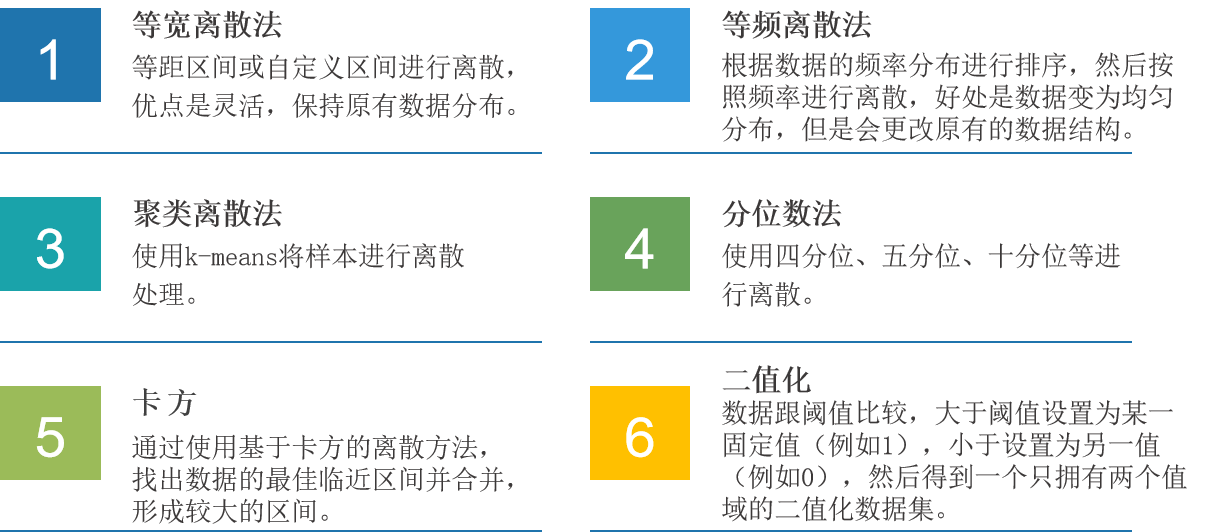

### 等宽法/距离区间法
使用等距或自定义区间的方式进行离散化，即将连续型变量的取值范围均匀划分成n等份，每份的间距相等。如将年龄字段划分为0-10岁为一组，10-20岁为一组……以此类推，其组距都为10。    
Pandas的cut方法：将数值数据转换为分类数据的方法

| 序号 | 函数      | 作用   | 主要参数                                                     | 备注                                                   |
| :---- | :--------- | :------ | :------------------------------------------------------------ | :------------------------------------------------------ |
| 1    | pd.cut()  | 值分箱 | x（待分箱数据）<br />bins（组距，分箱的取值依据）<br />right（默认True，左开右闭）<br />labels（分箱后的标签）<br /> include_lowest(第一个区间是否左包含)| 基于给定值的分箱。<br />bins可以是一个整数或者整数序列，如列表。<br />x must be 1-dimensional.<br /> |

In [2]:
age = pd.Series(np.random.randint(0,80,20))
age

0     53
1     21
2     51
3     30
4     39
5     17
6     78
7     48
8     14
9     43
10    71
11    70
12    25
13    52
14    53
15    27
16    60
17    69
18    67
19    26
dtype: int32

In [3]:
# 【1】当bins为整数时，表示将x分箱为bins份。注意：不是数量等分，是值的宽度【（max-min/）bins】等分。
# 把年龄分成3组，标签为A、B、C
pd.cut(age,bins = 3,labels = ['A','B','C'])

0     B
1     A
2     B
3     A
4     B
5     A
6     C
7     B
8     A
9     B
10    C
11    C
12    A
13    B
14    B
15    A
16    C
17    C
18    C
19    A
dtype: category
Categories (3, object): ['A' < 'B' < 'C']

In [10]:
# 【2】当bins为数字序列，如列表时，则按照给定的值区间进行划分。
# 0-6岁为婴幼儿；7-12岁为少儿；13-17岁为青少年；18-45岁为青年；46-69岁为中年；>69岁为老年。
df = pd.cut(age,bins = [0,6,12,17,45,69,200],labels =['婴幼儿','少儿','青少年','青年','中年','老年'] ,
       include_lowest = True)

In [11]:
# 统计每个年龄段的频次
df.value_counts()

中年     8
青年     6
少儿     2
青少年    2
老年     2
婴幼儿    0
Name: count, dtype: int64

### 等频法
等频法是将相同数量的记录放在每个区间，保证每个区间的数量基本一致。即将属性值分为具有相同宽度的区间，区间的个数k根据实际情况来决定。比如有60个样本，要将其分为k=3部分，则每部分的长度为20个样本。  
Pandas的qcut可以把一组数字按大小区间进行分区。

In [4]:
age = pd.Series(np.random.randint(0,80,20))
age

0     29
1     37
2     50
3     54
4     59
5     11
6      0
7     44
8     40
9      9
10     7
11    30
12    58
13    62
14    40
15    64
16    14
17    70
18    75
19    32
dtype: int32

In [6]:
# 【1】当q为整数，表示将x按照“数量”等分为q份。
pd.qcut(age,q =5)

0       (13.4, 35.0]
1       (35.0, 46.4]
2       (46.4, 59.6]
3       (46.4, 59.6]
4       (46.4, 59.6]
5     (-0.001, 13.4]
6     (-0.001, 13.4]
7       (35.0, 46.4]
8       (35.0, 46.4]
9     (-0.001, 13.4]
10    (-0.001, 13.4]
11      (13.4, 35.0]
12      (46.4, 59.6]
13      (59.6, 75.0]
14      (35.0, 46.4]
15      (59.6, 75.0]
16      (13.4, 35.0]
17      (59.6, 75.0]
18      (59.6, 75.0]
19      (13.4, 35.0]
dtype: category
Categories (5, interval[float64, right]): [(-0.001, 13.4] < (13.4, 35.0] < (35.0, 46.4] < (46.4, 59.6] < (59.6, 75.0]]

In [7]:
# 【2】当q为0-1之间的浮点数序列，如列表，表示将x按照给定列表的分位数进行划分。
df1 = pd.qcut(age,q = [0,0.25,0.5,0.75,1],labels = ['Q1以下','Q1-Q2','Q2-Q3','Q3以上'])

df1

0     Q1-Q2
1     Q1-Q2
2     Q2-Q3
3     Q2-Q3
4      Q3以上
5      Q1以下
6      Q1以下
7     Q2-Q3
8     Q1-Q2
9      Q1以下
10     Q1以下
11    Q1-Q2
12    Q2-Q3
13     Q3以上
14    Q1-Q2
15     Q3以上
16     Q1以下
17     Q3以上
18     Q3以上
19    Q1-Q2
dtype: category
Categories (4, object): ['Q1以下' < 'Q1-Q2' < 'Q2-Q3' < 'Q3以上']

In [8]:
# 统计每个标签数量
df1.value_counts()

Q1-Q2    6
Q1以下     5
Q3以上     5
Q2-Q3    4
Name: count, dtype: int64

qcut与cut的主要区别：  
qcut：传入参数，要将数据分成多少组，即组的个数，具体的组距是由代码计算。  
cut：传入参数，是分组依据。  

### 聚类离散化
一维聚类离散包括两个过程：选取聚类算法（K-Means算法）将连续属性值进行聚类；处理聚类之后得到k个簇并得到每个簇对应的分类值（类似这个簇的标记），将在同一个簇内的属性值做为统一标记。

In [17]:
pip install sklearn -i https://mirrors.tuna.tsinghua.edu.cn/

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sklearn (from versions: none)
ERROR: No matching distribution found for sklearn


原始数据概览:
            price
count  498.000000
mean   131.628514
std     76.321546
min     30.000000
25%     67.250000
50%    114.500000
75%    185.750000
max    299.000000
数据形状: (498, 1)


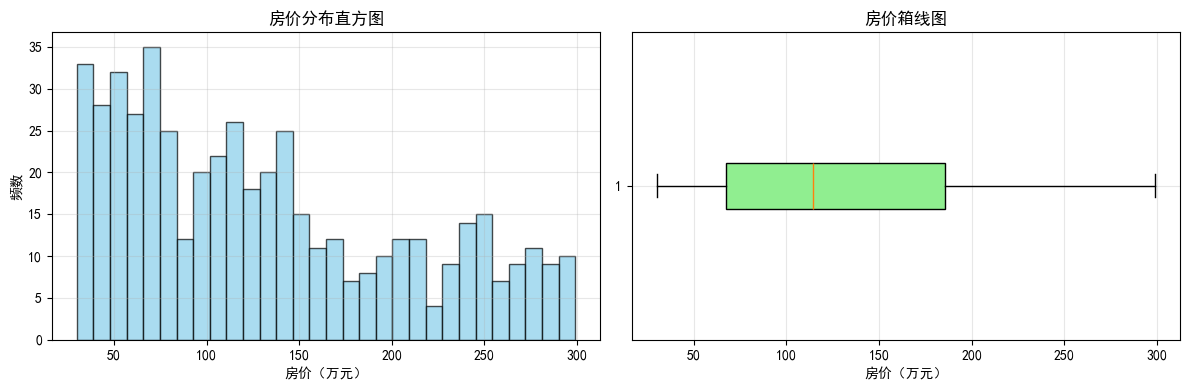


聚类统计信息:
               样本数  最小值  最大值     平均值    标准差
cluster_label                              
0              178   97  188  134.16  25.05
1              122  192  299  245.17  30.75
2              198   30   96   59.39  17.77

聚类中心: [ 59.39 134.16 245.17]
分箱边界: [np.int32(30), np.float64(96.78), np.float64(189.67), np.float64(299.1)]


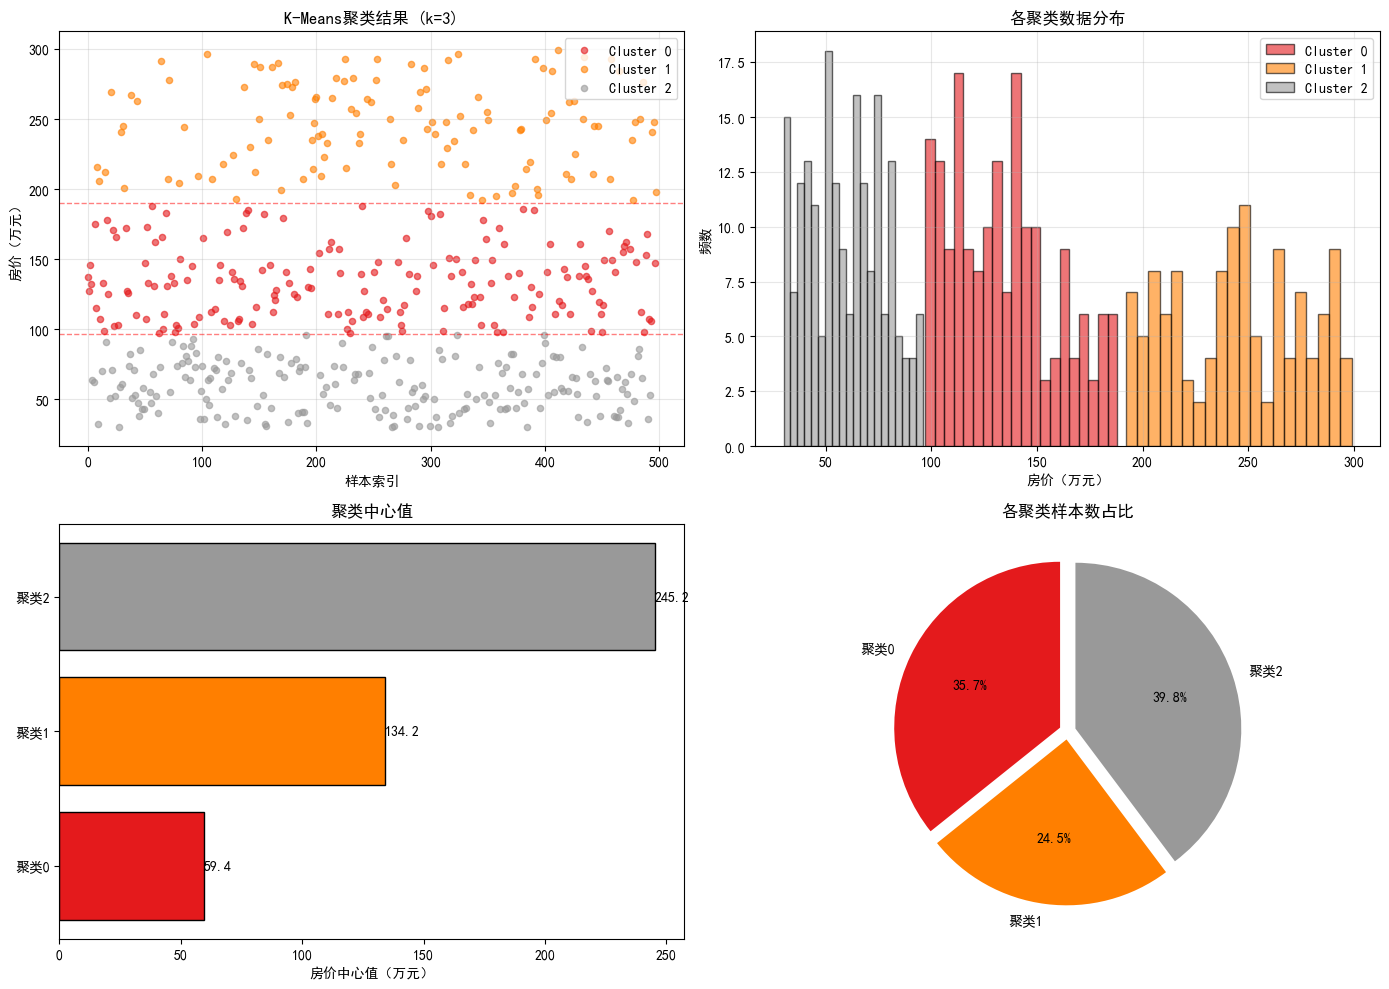

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# 设置中文字体（如果图表需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 生成模拟的一维房价数据（单位：万元）
np.random.seed(42)
n_samples = 500

# 模拟不同类型房价的分布
# 低价房：30-80万
low_price = np.random.randint(30, 80, n_samples//3)
# 中价房：80-150万
mid_price = np.random.randint(80, 150, n_samples//3)
# 高价房：150-300万
high_price = np.random.randint(150, 300, n_samples//3)

# 合并数据
house_prices = np.concatenate([low_price, mid_price, high_price])
np.random.shuffle(house_prices)  # 打乱顺序

# 创建DataFrame
df = pd.DataFrame(house_prices, columns=['price'])
print("=" * 60)
print("原始数据概览:")
print(df.describe())
print(f"数据形状: {df.shape}")
print("=" * 60)

# 可视化原始数据分布
def plot_original_data(data, bins=30):
    """绘制原始数据分布"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 直方图
    axes[0].hist(data, bins=bins, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0].set_xlabel('房价（万元）')
    axes[0].set_ylabel('频数')
    axes[0].set_title('房价分布直方图')
    axes[0].grid(True, alpha=0.3)
    
    # 箱线图
    axes[1].boxplot(data, vert=False, patch_artist=True, 
                   boxprops=dict(facecolor='lightgreen'))
    axes[1].set_xlabel('房价（万元）')
    axes[1].set_title('房价箱线图')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# 显示原始数据分布
fig1 = plot_original_data(df['price'].values)
plt.show()

# 第一步：使用K-Means进行聚类
def kmeans_discretization(data, n_clusters=3, random_state=42):
    """
    使用K-Means对一维数据进行聚类离散化
    
    参数:
    data: 一维数组
    n_clusters: 聚类数量
    random_state: 随机种子
    
    返回:
    clusters: 聚类标签数组
    centers: 聚类中心
    boundaries: 分箱边界
    """
    # 确保数据是二维的 (n_samples, 1)
    X = data.reshape(-1, 1)
    
    # 可选的：标准化数据（对于K-Means通常建议）
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 使用K-Means聚类
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    centers = scaler.inverse_transform(kmeans.cluster_centers_).flatten()
    
    # 计算分箱边界
    sorted_centers = np.sort(centers)
    boundaries = []
    
    # 使用相邻聚类中心的中点作为边界
    for i in range(len(sorted_centers) - 1):
        boundary = (sorted_centers[i] + sorted_centers[i + 1]) / 2
        boundaries.append(boundary)
    
    # 添加最小值和最大值作为边界
    boundaries = [data.min()] + boundaries + [data.max() + 0.1]  # 加0.1确保最大值被包含
    
    return clusters, sorted_centers, boundaries

# 应用聚类离散化
n_clusters = 3
clusters, centers, boundaries = kmeans_discretization(df['price'].values, n_clusters=n_clusters)

# 将聚类标签添加到原始数据
df['cluster_label'] = clusters
df['discrete_price'] = df['cluster_label'].map(lambda x: f'价格等级_{x+1}')

# 计算统计信息
cluster_stats = df.groupby('cluster_label').agg({
    'price': ['count', 'min', 'max', 'mean', 'std']
}).round(2)

# 重命名列
cluster_stats.columns = ['样本数', '最小值', '最大值', '平均值', '标准差']
print("\n聚类统计信息:")
print(cluster_stats)
print(f"\n聚类中心: {centers.round(2)}")
print(f"分箱边界: {[round(b, 2) for b in boundaries]}")

# 第二步：可视化聚类结果
def plot_clustering_results(df, centers, boundaries, n_clusters):
    """可视化聚类离散化结果"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 聚类结果散点图
    colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))
    for i in range(n_clusters):
        cluster_data = df[df['cluster_label'] == i]['price']
        axes[0, 0].scatter(cluster_data.index, cluster_data, 
                          color=colors[i], label=f'Cluster {i}', alpha=0.6, s=20)
    
    axes[0, 0].set_xlabel('样本索引')
    axes[0, 0].set_ylabel('房价（万元）')
    axes[0, 0].set_title(f'K-Means聚类结果 (k={n_clusters})')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 绘制分箱边界
    for boundary in boundaries[1:-1]:  # 跳过最小值和最大值
        axes[0, 0].axhline(y=boundary, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    # 2. 每个聚类的直方图
    for i in range(n_clusters):
        cluster_data = df[df['cluster_label'] == i]['price']
        axes[0, 1].hist(cluster_data, bins=20, alpha=0.6, 
                       label=f'Cluster {i}', color=colors[i], edgecolor='black')
    
    axes[0, 1].set_xlabel('房价（万元）')
    axes[0, 1].set_ylabel('频数')
    axes[0, 1].set_title('各聚类数据分布')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. 聚类中心可视化
    y_pos = np.arange(len(centers))
    axes[1, 0].barh(y_pos, centers, color=colors, edgecolor='black')
    axes[1, 0].set_yticks(y_pos)
    axes[1, 0].set_yticklabels([f'聚类{i}' for i in range(n_clusters)])
    axes[1, 0].set_xlabel('房价中心值（万元）')
    axes[1, 0].set_title('聚类中心值')
    
    # 在条形上添加数值
    for i, center in enumerate(centers):
        axes[1, 0].text(center, i, f'{center:.1f}', 
                       va='center', ha='left', fontweight='bold')
    
    # 4. 聚类样本数饼图
    cluster_counts = df['cluster_label'].value_counts().sort_index()
    axes[1, 1].pie(cluster_counts.values, labels=[f'聚类{i}' for i in cluster_counts.index],
                   autopct='%1.1f%%', startangle=90, colors=colors, explode=[0.05]*n_clusters)
    axes[1, 1].set_title('各聚类样本数占比')
    
    plt.tight_layout()
    return fig

# 显示聚类结果
fig2 = plot_clustering_results(df, centers, boundaries, n_clusters)
plt.show()

### 特征二值化
核心在于设定一个阈值，将特征与该阈值比较后，转化为0或1（只考虑某个特征出现与否，不考虑出现次数、程度），目的是将连续数值细粒度的度量转化为粗粒度的度量。  
当特征表示“出现次数”，但实际业务更关注“是否出现”时  
将灰度图像转换为黑白图像  
词袋模型（Bag-of-Words）的二值化表示

In [21]:
from sklearn.preprocessing import Binarizer
import numpy as np

data = [[1, 2, 4], [1, 2, 6], [3, 2, 2], [4, 3, 8]]

# 1. 对整个数据集
binar = Binarizer(threshold=3)
result_all = binar.fit_transform(data)
print("整体二值化:")
print(result_all)

# 2. 对单个样本
single = np.array(data[0]).reshape(1, -1)  # 关键：转换为二维
result_single = binar.transform(single)
print("\n单个样本二值化:")
print(result_single)

整体二值化:
[[0 0 1]
 [0 0 1]
 [0 0 0]
 [1 0 1]]

单个样本二值化:
[[0 0 1]]


## 属性构造
构造属性，也就是需要利用已有的属性集构造出新的属性，并加入到现有的集合属性中。  

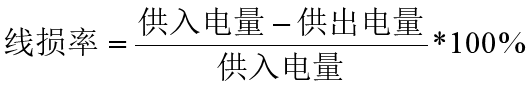

In [22]:
df = pd.DataFrame({
    '供入电量':[986,1208,1108,1082,1285],
    '供出电量':[912,1083,975,934,1102]
})
df[u'线损率'] = (df[u'供入电量'] - df[u'供出电量'])/df[u'供入电量']  #线损率计算
df

,供入电量,供出电量,线损率
0,986,912,0.075051
1,1208,1083,0.103477
2,1108,975,0.120036
3,1082,934,0.136784
4,1285,1102,0.142412


## 小波变换
小波变换表示可以把非平稳信号分解为表达不同层次、不同频带信息的数据序列。选取适当的小波系数，即完成了信号的特征提取。  
在信号处理、图像处理、语音识别、模式识别、量子物理等领域得到越来越广泛的应用，它被认为是近年来在工具及方法上的重大突破。

In [24]:
from scipy.io import loadmat     #mat是MATLAB专用格式，需要用loadmat读取它
mat = loadmat(r'数据源\leleccum.mat')   
signal = mat['leleccum'][0]
print("signal:",signal)

signal: [420.20278994 423.52653517 423.52271225 ... 323.96580997 323.2400761
 323.85476049]


In [26]:
import pywt      #导入PyWavelets
coeffs = pywt.wavedec(signal, 'bior3.7', level = 5) #双正交3.7小波，分解的层数为5层
#返回结果为level+1个数字，第一个数组为逼近系数数组，后面的依次是细节系数数组
print('coeffs:',coeffs)

coeffs: [array([2415.1478541 , 2395.74470824, 2402.22022728, 2408.90987352,
       2402.22022728, 2395.74470824, 2415.1478541 , 2369.53622493,
       1958.0913368 , 1983.87619596, 1901.68851538, 1651.86483216,
       1482.45129628, 1356.98779058, 1257.4459793 , 1265.75505172,
       1363.66712581, 1427.53767222, 1568.87951307, 1893.80694993,
       2295.89161125, 2555.9239482 , 2778.31817145, 2871.0940301 ,
       2954.38189098, 2981.0281365 , 2986.06286012, 3091.56214184,
       3085.0678644 , 2840.05639099, 2782.74679521, 2776.99922688,
       2833.0658032 , 2907.76710805, 2496.58749928, 2443.95791914,
       2338.50723857, 2394.15834442, 2186.86013504, 2142.10730351,
       2066.37469747, 2097.47366057, 2190.20987484, 2024.82470966,
       1999.88792082, 1761.22260043, 2012.8983115 , 1733.14320566,
       1955.69105593, 2296.53399998, 2332.11621828, 2436.91433782,
       2248.43497823, 1928.01215666, 1900.73383661, 1804.08152916,
       1596.93576991, 1375.26325034, 1301.52662997, 1

利用小波变换可以对声波信号进行特征提取，提取出可以代表声波信号的向量数据，即完成从声波信号到特征向量数据的变换。本例利用小波函数对声波信号数据进行分解，得到5个层次的小波系数。利用这些小波系数求得各个能量值，这些能量值即可作为声波信号的特征数据。

In [28]:
原始信号
    ↓
小波分解
    ├── 逼近系数（Approximation Coefficients）- 低频部分
    │   └── 信号的主要趋势、整体轮廓
    │
    └── 细节系数（Detail Coefficients）- 高频部分
        └── 信号的细节、波动、噪声

IndentationError: unexpected indent (1465165986.py, line 2)

## 数据规范化
数据规范化(又称归一化、数据无量纲化)主要包括：总和标准化、标准差标准化、极大值标准化、极差标准化。
不同评价指标往往具有不同的量纲，数值间的差别可能很大，不进行处理可能会影响到数据分析的结果。为了消除指标之间的量纲和取值范围差异的影响，需要进行标准化处理，将数据按照比例进行缩放，使之落入一个特定的区域，便于进行综合分析。

### Min-max 归一化
Min-max规范化（最小-最大规范化）也称为离差标准化，是对原始数据的线性变换，将数据值映射到[Ymin , Ymax]之间。公式如下。  
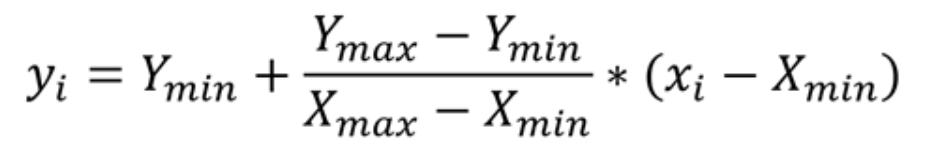  
如果映射的目标值域[Ymin , Ymax]为[0,1]，则公式如下，此时也称为数据归一化。  
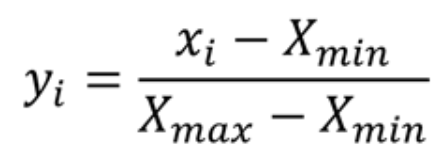

In [9]:
from sklearn import preprocessing #preprocessing模块，对数据进行了MinMaxScaler标准化（也称为归一化）
# 初始化数据，每一行表示一个样本，每一列表示一个特征
df = pd.DataFrame([[ 0., -3.,  1.],
              [ 3.,  1.,  2.],
              [ 0.,  1., -1.]])
# 将数据进行 [0,1] 规范化
min_max_scaler = preprocessing.MinMaxScaler()

# # 创建 MinMaxScaler 对象
minmax_x = min_max_scaler.fit_transform(df)
# # 拟合并转换数据
minmax_x

array([[0.        , 0.        , 0.66666667],
       [1.        , 1.        , 1.        ],
       [0.        , 1.        , 0.        ]])

### Z-Score 标准化
Z-Score规范化（零-均值规范化）也称标准差标准化，经过处理的数据的均值为0，标准差为1。这是当前用得最多的数据标准化方法。公式如下。
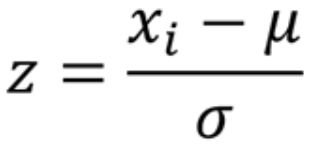

In [11]:
from sklearn import preprocessing
# 初始化数据，每一行表示一个样本，每一列表示一个特征
df = pd.DataFrame([[ 0., -3.,  1.],
              [ 3.,  1.,  2.],
              [ 0.,  1., -1.]])
# 将数据进行 Z-Score 规范化
scaled_x = preprocessing.scale(df)
scaled_x

array([[-0.70710678, -1.41421356,  0.26726124],
       [ 1.41421356,  0.70710678,  1.06904497],
       [-0.70710678,  0.70710678, -1.33630621]])

Z-Score规范化将数据集进行了规范化，数值都符合均值为0，标准差为1的正态分布。

### 小数定标规范化
小数定标规范化就是通过移动小数点的位置来进行规范化，用于消除单位影响。   
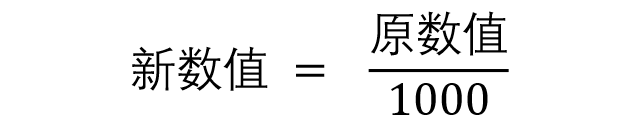  

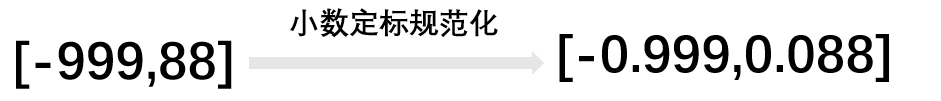

### 正则化
正则化(Normalization)是一种为了减小测试误差的行为。当利用复杂的模型拟合数据，出现过拟合现象而导致模型的泛化能力下降时，使用正则化可以降低模型的复杂度。  
本质是对某一问题加以先验的限制或约束以达到特定目的的一种手段或操作。  
主要思想是对每个样本计算其p-范数，然后对该样本中每个元素除以该范数，这样处理的结果是使得每个处理后样本的p-范数（L1-norm,L2-norm）等于1。
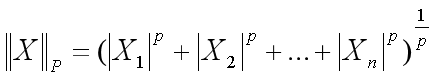
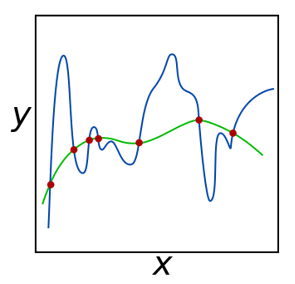

# 分组和聚合

分组与聚合是常见的数据变换操作，其中分组指根据分组条件（一个或多个键）将原数据拆分为若干个组；聚合指任何能从分组数据生成标量值的变换过程，过程中主要对各分组应用同一操作，并把操作后所得的结果整合到一起，生成一组新数据。  

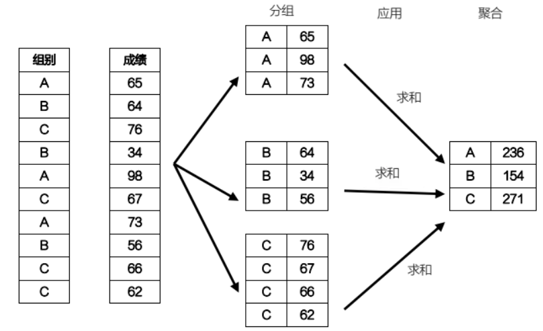

## 窗口函数
Pandas 提供了几种窗口函数，比如移动函数（rolling）、扩展函数（expanding）和指数加权函数（ewm）。  
目的：为了能更好地处理数值型数据。

### 移动窗口函数rolling()
rolling()函数又称移动窗口函数，它可以与聚合函数一起使用。Pandas为移动函数定义了专门的聚合方法，比如 rolling_mean()、rolling_count()和rolling_sum() 等。    
其语法格式如下。  
rolling(window=n, min_periods=None, center=False)  
window:默认值为1，表示窗口的大小，也就是观测值的数量  
min_periods:表示窗口的最小观察值，默认与window的参数值相等  
center：是否把中间值做为窗口标准，默认值为False

In [12]:
#生成时间序列
df = pd.DataFrame(np.random.randint(4,8,(8,4)),
                  index = pd.date_range('9/1/2022', periods=8),
                  columns = ['A', 'B', 'C', 'D'])
print(df)

#每3个数求一次均值
print(df.rolling(window = 3).mean())


            A  B  C  D
2022-09-01  7  4  6  5
2022-09-02  4  4  4  6
2022-09-03  6  6  4  4
2022-09-04  6  6  5  4
2022-09-05  4  4  7  6
2022-09-06  5  5  5  4
2022-09-07  7  6  6  7
2022-09-08  4  7  4  5
                   A         B         C         D
2022-09-01       NaN       NaN       NaN       NaN
2022-09-02       NaN       NaN       NaN       NaN
2022-09-03  5.666667  4.666667  4.666667  5.000000
2022-09-04  5.333333  5.333333  4.333333  4.666667
2022-09-05  5.333333  5.333333  5.333333  4.666667
2022-09-06  5.000000  5.000000  5.666667  4.666667
2022-09-07  5.333333  5.000000  6.000000  5.666667
2022-09-08  5.333333  6.000000  5.000000  5.333333


### 扩展窗口函数expanding()
expanding()函数又叫扩展窗口函数，扩展是指由序列的第一个元素开始，逐个向后计算元素的聚合值。

In [13]:
df = pd.DataFrame(np.random.randint(4,10,(10,4)),
      index = pd.date_range('9/1/2022', periods=10),
      columns = ['A', 'B', 'C', 'D'])
print(df)

print(df.expanding(min_periods = 3).mean())


            A  B  C  D
2022-09-01  9  4  6  7
2022-09-02  5  9  8  8
2022-09-03  4  6  6  6
2022-09-04  9  4  8  8
2022-09-05  9  5  9  6
2022-09-06  5  4  8  6
2022-09-07  4  5  7  4
2022-09-08  8  6  5  6
2022-09-09  7  5  7  7
2022-09-10  8  5  7  9
                   A         B         C         D
2022-09-01       NaN       NaN       NaN       NaN
2022-09-02       NaN       NaN       NaN       NaN
2022-09-03  6.000000  6.333333  6.666667  7.000000
2022-09-04  6.750000  5.750000  7.000000  7.250000
2022-09-05  7.200000  5.600000  7.400000  7.000000
2022-09-06  6.833333  5.333333  7.500000  6.833333
2022-09-07  6.428571  5.285714  7.428571  6.428571
2022-09-08  6.625000  5.375000  7.125000  6.375000
2022-09-09  6.666667  5.333333  7.111111  6.444444
2022-09-10  6.800000  5.300000  7.100000  6.700000


### 指数加权函数ewm()
ewn()函数先会对序列元素做指数加权运算，其次计算加权后的均值。该函数通过指定com、span或者halflife参数来实现指数加权移动。

In [14]:
df = pd.DataFrame(np.random.randint(4,10,(10,4)),
      index = pd.date_range('9/1/2022', periods=10),
      columns = ['A', 'B', 'C', 'D'])
print(df)
#设置com=0.5，先加权再求均值
print(df.ewm(com = 0.5).mean())

            A  B  C  D
2022-09-01  7  4  4  5
2022-09-02  8  4  5  8
2022-09-03  6  5  9  4
2022-09-04  4  5  9  9
2022-09-05  4  9  5  7
2022-09-06  6  7  9  6
2022-09-07  6  9  6  9
2022-09-08  6  4  5  9
2022-09-09  6  9  7  4
2022-09-10  7  9  5  6
                   A         B         C         D
2022-09-01  7.000000  4.000000  4.000000  5.000000
2022-09-02  7.750000  4.000000  4.750000  7.250000
2022-09-03  6.538462  4.692308  7.692308  5.000000
2022-09-04  4.825000  4.900000  8.575000  7.700000
2022-09-05  4.272727  7.644628  6.181818  7.231405
2022-09-06  5.425824  7.214286  8.063187  6.409341
2022-09-07  5.808783  8.405306  6.687100  8.137237
2022-09-08  5.936280  5.467988  5.562195  8.712500
2022-09-09  5.978762  7.822782  6.520780  5.570674
2022-09-10  6.659599  8.607607  5.506910  5.856896


## 分组函数

（1）数据的分组（groupby）是根据特定的一列或多列对数据进行分组，然后对分组后的每组数据分别进行分析。   
（2）pandas中的分组方法是使用groupby()方法，使用该方法分组后，会返回一个GroupBy对象，GroupBy对象中也提供了很多属性和方法。  
（3）实际处理中，可以将GroupBy对象想象成多个相对独立的DataFrame对象。因此，其一些操作方法和DataFrame对象类似，如可以使用常见的聚合操作，如max()、mean()、var()等等；也可以通过普通的[ ]进行数据选择与筛选等。  
（4）特别注意：在使用groupby()方法进行“基于多列”的分组处理后，会返回多重索引（MultiIndex）的DataFrame对象，应该尽量避免这种现象。因此，在进行“基于多列”的分组处理时，最好给groupby()方法中显式添加“as_index=False”的参数。

groupby(by=None, axis=0, level=None, as_index=True, sort=True, group_key=True, squeeze=< object object>, observed=False, dropna=True)  
by:表示分组条件	   
axis:表示分组操作的轴编号，默认为0，沿列操作  
as_index:表示聚合后新数据的索引是否为分组标签的索引,默认True  
sort:表示是否对分组索引进行排序,默认True  
group_keys:表示是否显示分组标签的名称,默认True  
level:表示标签索引所在的级别,默认None

In [15]:
# 创建一个简单的DataFrame
data = {
    'A': ['foo', 'bar', 'foo', 'bar', 'foo', 'bar', 'foo', 'foo'],
    'B': np.random.randint(1,10,8),
    'C': np.random.randint(1,10,8)
}
df = pd.DataFrame(data)
df

,A,B,C
0,foo,5,9
1,bar,7,5
2,foo,3,8
3,bar,8,7
4,foo,5,7
5,bar,1,7
6,foo,6,9
7,foo,3,1


In [16]:
# 使用groupby按列'A'进行分组
df.groupby('A')


In [15]:
# 计算每个组的平均值
df.groupby('A').mean()

,B,C
A,,
bar,5.0,5.666667
foo,5.0,5.600000


In [17]:
# 计算每个组的总和
df.groupby('A').sum()

,B,C
A,,
bar,16,19
foo,22,34


In [18]:
# 1.agg一起使用
df1 = pd.DataFrame({
            'name': ['香蕉', '菠菜', '糯米', '糙米', '丝瓜', '冬瓜', '柑橘', '苹果', '橄榄油'],
            'category': ['水果', '蔬菜', '米面', '米面', '蔬菜', '蔬菜', '水果', '水果', '粮油'],
            'price': [3.5, 6, 2.8, 9, 3, 2.5, 3.2, 8, 18],
            'count': [2, 1, 3, 6, 4, 8, 5, 3, 2]
        })
df1

,name,category,price,count
0,香蕉,水果,3.5,2
1,菠菜,蔬菜,6.0,1
2,糯米,米面,2.8,3
3,糙米,米面,9.0,6
4,丝瓜,蔬菜,3.0,4
5,冬瓜,蔬菜,2.5,8
6,柑橘,水果,3.2,5
7,苹果,水果,8.0,3
8,橄榄油,粮油,18.0,2


In [19]:
# 根据category分组，对价格进行求和
df1.groupby(by = 'category')['price'].sum(),df1.groupby(by = 'category')['price'].agg('sum')

(category
 水果    14.7
 米面    11.8
 粮油    18.0
 蔬菜    11.5
 Name: price, dtype: float64,
 category
 水果    14.7
 米面    11.8
 粮油    18.0
 蔬菜    11.5
 Name: price, dtype: float64)

In [20]:
# 根据category分组，对价格以及数量求和、求均值
df1.groupby('category')[['price','count']].agg(['sum','mean'])

price            count          
           sum       mean   sum      mean
category                                 
水果        14.7   4.900000    10  3.333333
米面        11.8   5.900000     9  4.500000
粮油        18.0  18.000000     2  2.000000
蔬菜        11.5   3.833333    13  4.333333

In [21]:
# 根据category分组，对价格求均值，对数量求和
df1.groupby(by = 'category').agg({'price':'mean','count':'sum'})

,price,count
category,,
水果,4.900000,10
米面,5.900000,9
粮油,18.000000,2
蔬菜,3.833333,13


In [22]:
# 2.与transform()一起使用
# 新增一列价格均值的列，值为不同种类的价格均值
df1['价格的均值'] = df1.groupby('category')['price'].transform('mean')
df1

,name,category,price,count,价格的均值
0,香蕉,水果,3.5,2,4.900000
1,菠菜,蔬菜,6.0,1,3.833333
2,糯米,米面,2.8,3,5.900000
3,糙米,米面,9.0,6,5.900000
4,丝瓜,蔬菜,3.0,4,3.833333
5,冬瓜,蔬菜,2.5,8,3.833333
6,柑橘,水果,3.2,5,4.900000
7,苹果,水果,8.0,3,4.900000
8,橄榄油,粮油,18.0,2,18.000000


In [23]:
# 新增一列数量+10的列count1，值为count列的值+10
df1['count1'] = df1.groupby('category')['count'].transform(lambda x: x+10)
df1

,name,category,price,count,价格的均值,count1
0,香蕉,水果,3.5,2,4.900000,12
1,菠菜,蔬菜,6.0,1,3.833333,11
2,糯米,米面,2.8,3,5.900000,13
3,糙米,米面,9.0,6,5.900000,16
4,丝瓜,蔬菜,3.0,4,3.833333,14
5,冬瓜,蔬菜,2.5,8,3.833333,18
6,柑橘,水果,3.2,5,4.900000,15
7,苹果,水果,8.0,3,4.900000,13
8,橄榄油,粮油,18.0,2,18.000000,12


In [24]:
# 3.与apply函数一起使用
data = {
    'A': ['foo', 'bar', 'foo', 'bar', 'foo', 'bar', 'foo', 'foo'],
    'D': np.random.randint(1,10,8),
    'E': np.random.randint(1,10,8)
}
df2 = pd.DataFrame(data)
df2

,A,D,E
0,foo,6,6
1,bar,5,2
2,foo,6,9
3,bar,7,1
4,foo,3,6
5,bar,3,9
6,foo,7,8
7,foo,3,9


In [25]:
# 计算每个分组中每列的最大值与最小值的差
def range_diff(s):
    return s.max() - s.min()

In [26]:
# 按A列分组，每一列应用这个函数
df2.groupby(by = 'A').apply(range_diff)

,D,E
A,,
bar,4,8
foo,4,3


In [27]:
# 4.与filter()一起使用
# 组的大小大于3
data = {
    'Salesperson': ['Alice', 'Alice', 'Bob', 'Bob', 'Charlie', 'Charlie'],
    'Product': ['A', 'B', 'A', 'B', 'A', 'B'],
    'Sales': [100, 150, 80, 120, 200, 180],
    'Month': [1, 2, 1, 2, 1, 2]
}
print(type(data))
df3 = pd.DataFrame(data)
df3

<class 'dict'>


,Salesperson,Product,Sales,Month
0,Alice,A,100,1
1,Alice,B,150,2
2,Bob,A,80,1
3,Bob,B,120,2
4,Charlie,A,200,1
5,Charlie,B,180,2


In [28]:
# 只保留总销售额超过250的销售员的所有记录
df3.groupby(by = 'Salesperson').filter(lambda x : x['Sales'].sum() > 250)

,Salesperson,Product,Sales,Month
4,Charlie,A,200,1
5,Charlie,B,180,2


## 聚合函数
数据聚合是指任何能够从数组产生标量的值的数据转换过程。  
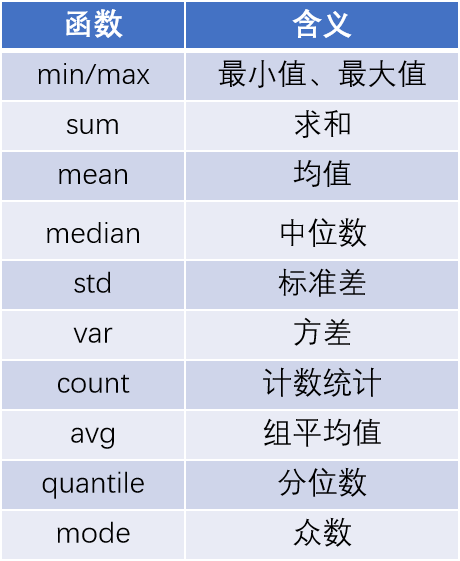

### agg()函数
Pandas中的agg()函数为aggregate的缩写，是一个功能非常强大的函数，在Pandas中可以利用agg()函数对Series、DataFrame以及groupby()后的结果进行聚合操作。  
df.agg（func,axis = 0,* args,** kwargs ）
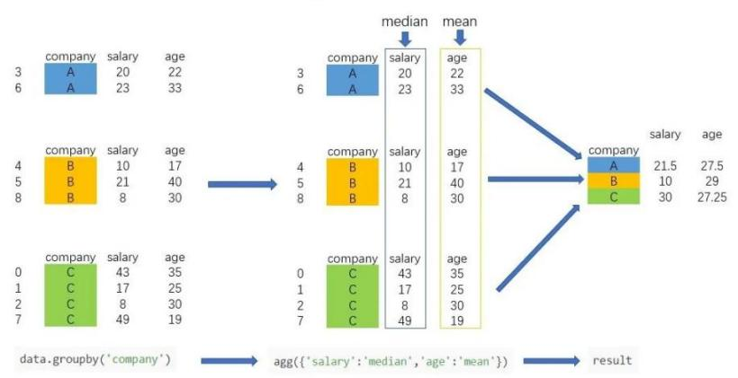

### transform()方法
transform()是pandas中的转换函数，对DataFrame执行传入的函数后返回一个相同形状的DataFrame。主要用于对DataFrame中的数据进行转换。  
函数用途：转换值、组合groupby()、过滤数据、在组级别处理缺失值。
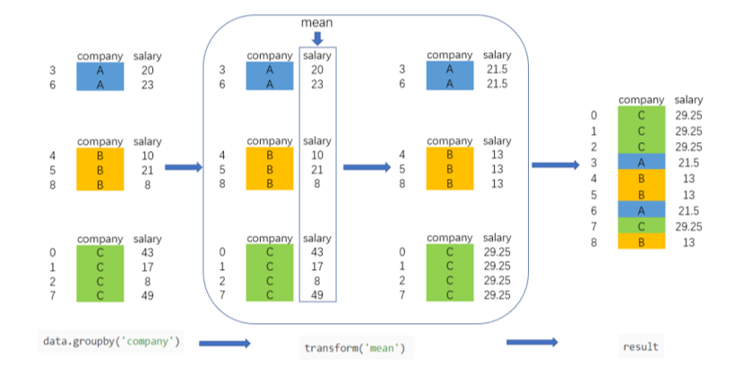

### 行列应用apply函数
apply()是Pandas库的一个很重要的函数，多和groupby()函数一起用，也可以直接用于DataFrame和Series对象，主要用于数据聚合运算，可以很方便的对分组进行现有的运算和自定义的运算。apply()的使用是十分灵活的，它可以在许多标准用例中替代聚合和转换，另外还可以处理一些比较特殊的用例，apply()会将待处理的对象拆分为多个片段，然后对各片段调用传入的函数，最后尝试将各个片段组合在一起。  

apply(func, axis=0, broadcast=None, raw=False, reduce=None,result_type=None, args=(), **kwds)  

func：应用于每一列或每一行的函数，这个函数可以是Python内置函数、Pandas或其他库中的函数、自定义函数、匿名函数  
axis：设置批处理函数按列还是按行应用，0或index表示按列应用函数，1或columns表示按行应用函数，默认值为0  
raw：设置将列/行作为Series对象传递给函数，还是作为ndarray对象传递给函数。raw是bool类型，默认为False  
result_type：当axis=1时，设置返回结果的类型和样式，支持{‘expand’, ‘reduce’, ‘broadcast’, None}四种类型，默认为None  
args：传给应用函数func的位置参数，args接收的数据类型为元组，如果只有一个位置参数要注意加逗号  
**kwds：如果func中有关键字参数，可以传给

### filter()
DataFrame/Series的filter()方法用于根据标签过滤行或列（不常用作值过滤）  
在groupby操作中，用于根据分组统计特性过滤整个分组。 

filter(func, dropna=True)  

func：函数，接收每个分组DataFrame，返回布尔值  

# 轴向旋转
数据的轴向旋装主要是重新指定一组数据的行索引或列索引，以达到重新组织数据结构的目的。即轴向旋转(pivot)是将“长格式”旋转为“宽格式”。

## Pandas透视表
| 序号 | 函数          | 作用     | 主要参数                                    | 备注                                                         |
| :---- | :------------- | :-------- | :------------------------------------------- | :------------------------------------------------------------ |
| 1    | pivot()       | 整理透视 | values<br />index<br />columns<br />        | 通过指定的索引和列对数据**进行重塑**，**无法聚合**（注意：**无法聚合，只能重塑结构，如“一维”变成二维**）。即如果指定的 index + columns 构成的数据里面存在**重复的情况，将会报错。** |
| 2    | pivot_table() | 聚合透视 | values<br />index<br />columns<br />aggfunc | 通过指定的索引和列对数据进行重塑，**同时进行聚合操作**。<br />**aggfunc**表示聚合（Aggregate）方式，默认是'mean'。 |  

### pivot()方法

In [29]:
df = pd.DataFrame({
    '姓名': ['张三', '李四', '王五', '张三', '李四', '王五'],
    '科目': ['语文', '语文', '语文', '数学', '数学', '数学'],
    '成绩': [81, 83, 85, 89, 98, 80]
},index = range(1,7))
df

,姓名,科目,成绩
1,张三,语文,81
2,李四,语文,83
3,王五,语文,85
4,张三,数学,89
5,李四,数学,98
6,王五,数学,80


In [30]:
df.pivot(index = '姓名',columns = '科目',values = '成绩')

科目,数学,语文
姓名,,
张三,89,81
李四,98,83
王五,80,85


In [31]:
df.groupby('姓名').sum()

,科目,成绩
姓名,,
张三,语文数学,170
李四,语文数学,181
王五,语文数学,165


In [32]:
result = df.pivot_table(index='姓名',values='成绩',aggfunc='sum')
result

,成绩
姓名,
张三,170
李四,181
王五,165


In [33]:
df.pivot(index = '姓名',columns = '科目',values = '成绩')

科目,数学,语文
姓名,,
张三,89,81
李四,98,83
王五,80,85


In [34]:
df.pivot(index = '姓名',columns = '科目',values = '成绩')

科目,数学,语文
姓名,,
张三,89,81
李四,98,83
王五,80,85


In [35]:
import pandas as pd

df = pd.DataFrame({
    'A': [5, 5, 10, 9, 4],
    'B': [10, 5, 8, 3, 10],
    'C': [8, 6, 8, 10, 8]
})

# 插入新列 A_，值为 0，放在最前面
df.insert(0, 'A_', 0)

print(df)

   A_   A   B   C
0   0   5  10   8
1   0   5   5   6
2   0  10   8   8
3   0   9   3  10
4   0   4  10   8


### pivot_table()方法

In [36]:
df1 = pd.read_excel(r'数据源/销售业绩表.xlsx')
df1.head(5)

,订单编号,销售日期,区域,业务员,产品代码,成本价格,销售价格,销售数量,成本合计,销售金额,销售毛利
0,2085998,2021-01-01,广州,姚伟平,PD2,70.870000,139.0,40,2834.800000,5560.0,2725.200000
1,2085999,2021-01-01,广州,姚伟平,PA3,13.710000,26.9,40,548.400000,1076.0,527.600000
2,2086000,2021-01-01,北京,陆琳艳,PD4,14.915532,42.0,90,1342.397912,3780.0,2437.602088
3,2086001,2021-01-01,厦门,朱佳鸣,PD2,91.425784,139.0,180,16456.641177,25020.0,8563.358823
4,2086002,2021-01-01,广州,杨曦,PD2,91.425784,139.0,180,16456.641177,25020.0,8563.358823


In [46]:
# 练习：业务员“姚伟平”销售产品“PA3”的总数量
# 方法1
df1[(df1['业务员'] == '姚伟平') & (df1['产品代码'] == 'PA3')]['销售数量'].sum()

np.int64(730)

In [11]:
#不同区域的销售金额
df1.groupby('区域')['销售金额'].sum()

区域
上海    6726222.1
北京    6540038.7
厦门    7132923.6
广州    5516959.4
Name: 销售金额, dtype: float64

In [14]:
#不同区域的销售金额
result = df1.pivot_table(index='区域',values='销售金额',aggfunc='sum')
result

,销售金额
区域,
上海,6726222.1
北京,6540038.7
厦门,7132923.6
广州,5516959.4


In [49]:
df = df1.groupby(by = ['业务员','产品代码'])['销售数量'].sum()
df['姚伟平']

产品代码
PA1     380
PA2    1120
PA3     730
PA4     400
PA5     870
PD1     200
PD2     360
PD3     250
PD4     710
PD5     720
Name: 销售数量, dtype: int64

In [50]:
# 方法2
df1.pivot_table(index = '业务员',columns = '产品代码',values = '销售数量',aggfunc = 'sum')

产品代码,PA1,PA2,PA3,PA4,PA5,PD1,PD2,PD3,PD4,PD5
业务员,,,,,,,,,,
严晓乐,320.0,370.0,200.0,480.0,740.0,480.0,1020.0,290.0,180.0,240.0
俞凌杰,720.0,590.0,380.0,400.0,580.0,950.0,540.0,290.0,950.0,160.0
刘芳芳,520.0,310.0,510.0,60.0,740.0,550.0,860.0,690.0,260.0,240.0
姚伟平,380.0,1120.0,730.0,400.0,870.0,200.0,360.0,250.0,710.0,720.0
姜华,440.0,270.0,240.0,340.0,970.0,450.0,250.0,660.0,600.0,360.0
孙峻,330.0,150.0,630.0,780.0,540.0,NaN,250.0,580.0,910.0,750.0
张洁如,600.0,360.0,230.0,640.0,420.0,860.0,150.0,500.0,930.0,240.0
朱佳鸣,590.0,300.0,270.0,600.0,590.0,570.0,440.0,340.0,100.0,370.0
朱建波,530.0,1350.0,180.0,780.0,410.0,830.0,340.0,670.0,560.0,710.0


In [52]:
# 按照区域和业务员为行
df1.pivot_table(index = ['区域','业务员'],columns = '产品代码',values = '销售数量',aggfunc = 'sum',margins = True
                ,margins_name = '总计')

产品代码        PA1      PA2     PA3     PA4      PA5      PD1     PD2      PD3  \
区域 业务员                                                                        
上海 严晓乐    320.0    370.0   200.0   480.0    740.0    480.0  1020.0    290.0   
   孙峻     330.0    150.0   630.0   780.0    540.0      NaN   250.0    580.0   
   欧金燕    440.0    620.0   520.0   140.0    660.0    650.0   410.0    310.0   
   沈丽霞    310.0    370.0   880.0   350.0    450.0    350.0   230.0    590.0   
   许春燕    780.0    690.0   340.0   110.0    490.0    440.0   200.0    660.0   
   许连生    980.0    180.0   420.0   670.0    470.0    320.0   330.0    740.0   
北京 姜华     440.0    270.0   240.0   340.0    970.0    450.0   250.0    660.0   
   胡小楠   1040.0    270.0   390.0  1150.0    430.0    910.0   530.0    750.0   
   陆琳艳    270.0    670.0   550.0   180.0    350.0    290.0   640.0    930.0   
   陈启明    200.0    410.0   690.0   390.0    960.0    660.0   640.0    810.0   
   黄秋云    650.0    410.0   430.0   630.0    220.0    660.0   100.0    630.0   
厦门 刘芳芳    520.0    310.0   510.0    60.0    740.0    550.0   860.0    690.0   
   张洁如    600.0    360.0   230.0   640.0    420.0    860.0   150.0    500.0   
   朱佳鸣    590.0    300.0   270.0   600.0    590.0    570.0   440.0    340.0   
   朱建波    530.0   1350.0   180.0   780.0    410.0    830.0   340.0    670.0   
   蒋英玲    410.0    980.0   290.0   300.0    430.0    620.0   390.0    840.0   
广州 俞凌杰    720.0    590.0   380.0   400.0    580.0    950.0   540.0    290.0   
   姚伟平    380.0   1120.0   730.0   400.0    870.0    200.0   360.0    250.0   
   杨曦     520.0    380.0   710.0   640.0    310.0    540.0   450.0    460.0   
   袁青洪    590.0    570.0   430.0   440.0    510.0    550.0   680.0    400.0   
总计      10620.0  10370.0  9020.0  9480.0  11140.0  10880.0  8810.0  11390.0   

产品代码        PD4     PD5      总计  
区域 业务员                           
上海 严晓乐    180.0   240.0    4320  
   孙峻     910.0   750.0    4920  
   欧金燕    750.0   190.0    4690  
   沈丽霞    710.0   350.0    4590  
   许春燕    740.0   280.0    4730  
   许连生    440.0   870.0    5420  
北京 姜华     600.0   360.0    4580  
   胡小楠    350.0   550.0    6370  
   陆琳艳    650.0   810.0    5340  
   陈启明    400.0   300.0    5460  
   黄秋云    180.0   100.0    4010  
厦门 刘芳芳    260.0   240.0    4740  
   张洁如    930.0   240.0    4930  
   朱佳鸣    100.0   370.0    4170  
   朱建波    560.0   710.0    6360  
   蒋英玲    210.0   790.0    5260  
广州 俞凌杰    950.0   160.0    5560  
   姚伟平    710.0   720.0    5740  
   杨曦     630.0   590.0    5230  
   袁青洪    370.0   460.0    5000  
总计      10630.0  9080.0  101420

## melt()方法
melt()是pandas中用于数据重塑的重要方法，它将DataFrame从宽格式转换为长格式，是数据透视的逆操作。这在数据清洗、分析和可视化中非常有用。    
df.melt(id_vars=None, value_vars=None, var_name=None, value_name=‘value’, col_level=None, ignore_index=True)  

DataFrame.melt(
    id_vars=None,           # 保持不变的列（标识变量）
    value_vars=None,        # 要"融化"的列（测量变量）
    var_name=None,          # 变量名列的名称
    value_name='value',     # 值列的名称
    ignore_index=True       # 是否忽略原始索引
)

In [54]:
# 创建示例数据
data = {
    'Country': ['USA', 'China', 'India'],
    '2020_GDP': [20.94, 14.72, 2.62],
    '2021_GDP': [23.00, 17.73, 3.18],
    '2020_Population': [331.0, 1444.2, 1380.0],
    '2021_Population': [332.9, 1448.5, 1396.4]
}
df = pd.DataFrame(data)
df

,Country,2020_GDP,2021_GDP,2020_Population,2021_Population
0,USA,20.94,23.00,331.0,332.9
1,China,14.72,17.73,1444.2,1448.5
2,India,2.62,3.18,1380.0,1396.4


In [55]:
# 将所有数值列融化
df.melt(id_vars = ['Country'])

,Country,variable,value
0,USA,2020_GDP,20.94
1,China,2020_GDP,14.72
2,India,2020_GDP,2.62
3,USA,2021_GDP,23.00
4,China,2021_GDP,17.73
5,India,2021_GDP,3.18
6,USA,2020_Population,331.00
7,China,2020_Population,1444.20
8,India,2020_Population,1380.00
9,USA,2021_Population,332.90


In [58]:
# 指定要融化的列
df.melt(id_vars = ['Country'],value_vars = ['2020_GDP','2021_GDP'],
       var_name = 'Year',
       value_name = 'GDP')
 # 只融化GDP列
# 自定义变量列名
  # 自定义值列名


,Country,Year,GDP
0,USA,2020_GDP,20.94
1,China,2020_GDP,14.72
2,India,2020_GDP,2.62
3,USA,2021_GDP,23.00
4,China,2021_GDP,17.73
5,India,2021_GDP,3.18


# 哑变量处理与面元切分

## 哑变量处理
哑变量又称虚拟变量，是人为虚设的变量，用来反映某个变量的不同类别，常用取值为0和1，0代表否，1代表是。哑变量用以反映质的属性的一个人工变量。

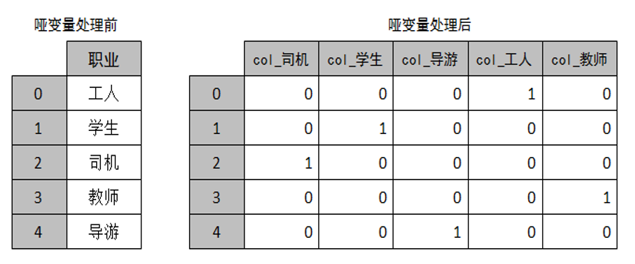

Pandas中使用get_dummies()函数对类别数据进行哑变量处理，并在处理后返回一个哑变量矩阵。它将分类变量转换为机器学习算法可处理的数值形式.这是特征工程中处理分类数据的关键步骤。  

get_dummies(data,prefix=None, prefix_sep='_', dummy_na=False,columns=None, sparse=False, drop_first=False, dtype=None)  
data：表示待处理的类别数据，可以是数组、DataFrame类或Series类对象。  
prefix：表示列索引名称的前缀，默认为None。  
prefix_sep：表示附加前缀的分隔符，默认为“_”。  
dummy_na：表示是否为NaN添加以列，默认为False。  
columns：表示哑变量处理的列索引名称，默认为None。  
sparse： 表示哑变量是否系数，默认为False。  
drop_first：表示是否从K个分类级别总删除第一个级别，以获得K-1个分类级别，默认为False。

In [59]:
# 创建示例数据
df = pd.DataFrame({
    '用户ID': [1, 2, 3, 4, 5],
    '性别': ['男', '女', '男', '女', '男'],
    '城市': ['北京', '上海', '广州', '北京', '深圳'],
    '年龄段': ['青年', '中年', '青年', '老年', '中年'],
    '活跃度': [0.8, 0.6, 0.9, 0.5, 0.7]
})
df

,用户ID,性别,城市,年龄段,活跃度
0,1,男,北京,青年,0.8
1,2,女,上海,中年,0.6
2,3,男,广州,青年,0.9
3,4,女,北京,老年,0.5
4,5,男,深圳,中年,0.7


In [61]:
# 基本哑变量转换
pd.get_dummies(df,dtype = int)

,用户ID,活跃度,性别_女,性别_男,城市_上海,城市_北京,城市_广州,城市_深圳,年龄段_中年,年龄段_老年,年龄段_青年
0,1,0.8,0,1,0,1,0,0,0,0,1
1,2,0.6,1,0,1,0,0,0,1,0,0
2,3,0.9,0,1,0,0,1,0,0,0,1
3,4,0.5,1,0,0,1,0,0,0,1,0
4,5,0.7,0,1,0,0,0,1,1,0,0


In [62]:
# 指定要转换的列
pd.get_dummies(df,columns = ['性别','城市'],dtype = int)

,用户ID,年龄段,活跃度,性别_女,性别_男,城市_上海,城市_北京,城市_广州,城市_深圳
0,1,青年,0.8,0,1,0,1,0,0
1,2,中年,0.6,1,0,1,0,0,0
2,3,青年,0.9,0,1,0,0,1,0
3,4,老年,0.5,1,0,0,1,0,0
4,5,中年,0.7,0,1,0,0,0,1


## 面元切分
面元划分是指数据被离散化处理，按一定的映射关系划分为相应的面元（可以理解为区间），只适用于连续数据。连续数据又称连续变量，指在一定区间内可以任意取值的数据，该类型数据的特点是数值连续不断，相邻两个数值可作无限分割。  
为了便于分析，连续数据常常被离散化或拆分为“面元”（bin），用pd.cut()函数可以实现。

# 数据转换

## 指定类型
数据转换是将数据从一种形式或格式转换为另一种形式或格式的过程，以满足特定需求或分析目的。数据转换涵盖了多种类型，包括数据结构、数据类型和数据数值等转换。例如，将Python列表转换为Pandas数据对象，将字符串类型转换为日期类型。  

s.to_frame()、df.to_dict()、s.tolist()、df.values.tolist()、df.values.flatten().tolist()  
pd.to_numeric()、pd.to_datetime()、pd.to_timedelta()

### pd.to_numeric()函数
pd.to_numeric()函数用于将一个或多个对象转换为数值类型（numeric），尤其是在处理混合类型的数据时非常有用。其基本语法和主要参数如下：  
pd.to_numeric(arg, errors='raise')
+ arg：要转换的对象。可以是单个标量、列表、Series、DataFrame或其他可迭代对象。
+ errors：指定如何处理转换错误的参数。可选值包括 'raise'（默认，如果转换错误则引发异常）、'coerce'（将转换错误的值设置为NaN）和'ignore'（保留转换错误的原始值）。

In [65]:
# 将列表中元素转换成数值类型，并加10。
pd.to_numeric(['1','2','A'],errors = 'coerce') + 10

array([11., 12., nan])

In [70]:
# 转换位数值型，不能转换的转换为NAN并且填充8然后整体+10
import pandas as pd

# 修复方式：先变成 Series，利用 Series 的 str 方法或直接处理
s = pd.Series(['1','2','A'])
s_numeric = pd.to_numeric(s, errors='coerce')
result = s_numeric.fillna(8) + 10
print(result)

0    11.0
1    12.0
2    18.0
dtype: float64


### pd.to_datetime()
pd.to_datetime() 函数用于将一个或多个对象转换为日期时间类型（datetime）。其基本语法和主要参数如下：  
pd.to_datetime(arg, format=None, errors='raise',unit=None)
+ arg：要转换的日期和时间数据。可以是单个日期/时间字符串、日期/时间列表、Series、DataFrame或其他可迭代对象。
+ format：指定日期/时间字符串的解析格式。有关format格式控制符号请参考：https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior
+ errors：指定如何处理转换错误的参数。可选值包括 'raise'（默认，如果转换错误则引发异常）、'coerce'（将转换错误的值设置为NaT）和'ignore'（保留转换错误的原始值）。
+ unit：时间单位。如果提供了单位（如's'表示秒），则将转换为给定的单位。默认为None，表示ns。  

一些相关概念：  
+ **日期（date）**：即年（year）、月（month）、日（day）的组合。如：2022年1月1日、**2022-01-01**、2022/1/1、20220101。  
+ **时间（time）**：即时（hour）、分（minute）、秒（second）以及纳秒（nanosecond）的组合。如：5:15:50，5:15:50.285714285。$1s=10^3ms=10^6μs=10^9ns=10^12ps$。  
+ **日期时间（datetime）**：即年-月-日 时:分:秒.纳秒的组合。如：2022-01-01 17:08:34.285714285。pandas中，这种日期时间类型数据的类型一般是**datetime64[ns]**，精确到纳秒，注意，在写的时候必须写64。  
+ **时间戳（Timestamp）**：时间轴上的一个时刻（点）。其起始原点一般指格林威治时间**1970-01-01 00:00:00:（北京时间1970-01-01 08:00:00:）**。因此，时间戳一般也理解为起始原点到某个时刻的**总秒数**。  
+ **时段（Period）**：表示一段时间，如1年、3年、1个月、10天、30秒等。pandas中，时段长短一般由**freq**参数确定，freq='Y'、freq='3Y'、freq='M'、freq='10D'、freq='M'、freq='30S'等。  
+ **时间间隔（Timedetla）**：表示两个时间之间的间隔，一般以天以及时、分、秒、毫秒等为计量标准。如：pd.Timestamp('2200-02-02 10:00:00.123456789') - pd.Timestamp('2000-01-01 00:00:00') = Timedelta('73081 days 10:00:00.123456789')。
+ 时段和时间间隔不同，时段就是一段时间，是一段时间的长度，没有特定的起始时间或结束时间，**更多是用来表示一种频率**；时间间隔一般特指某个结束时间与某个起始时间的差。

+ 时间字符串**格式控制**符号详见：https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior  
+ 时段频率（freq参数）控制符号详见：https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior. 
+ 主要时段频率控制符号：Y（年）、M（月）、D（天）、H（小时）、T（分钟）、S（秒）、W（周）、Q（季度）

In [71]:
# 指定unit，表示在1970-01-01 00:00:00的基础上增加10个unit。
pd.to_datetime(10,unit = 's'),pd.to_datetime(10,unit = 'D')

(Timestamp('1970-01-01 00:00:10'), Timestamp('1970-01-11 00:00:00'))

In [72]:
# 'ABC'无法转换成日期时间，coerce表示转换失败时，转换为NaT。
pd.to_datetime(['2023-01-01','ABC','2023年12月12日'],errors = 'coerce')

DatetimeIndex(['2023-01-01', 'NaT', 'NaT'], dtype='datetime64[ns]', freq=None)

年：%Y - 四位数的年份（例如：2023）  %y - 两位数的年份（00-99）  
月：%m - 两位数的月份（01-12）  %b - 月份缩写（Jan, Feb, ..., Dec）  %B - 月份全称（January, February, ..., December）  
日：%d - 两位数的日期（01-31）  
时：%H - 24小时制的小时（00-23）  %I - 12小时制的小时（01-12）  
分：%M - 分钟（00-59）  
秒：%S - 秒（00-59）  
微秒：%f - 微秒（000000-999999）  
上午/下午：%p - AM或PM  

In [74]:
# 指定format，表示将'2023-03-01'按照format格式进行解析。
pd.to_datetime(20250301221835,format = '%Y%m%d%H%M%S')

Timestamp('2025-03-01 22:18:35')

## 值处理：replace替换元素
df.replace()可以按照“单元格匹配”方式进行元素替换。与str.replace()不同，df.replace()支持用列表、字典等方式进行一对多，多对多的替换操作。

In [75]:
df = pd.DataFrame([ ['12', '34'], ['123', '134'], ['12', '12']], columns=['A', 'B'])
df

,A,B
0,12,34
1,123,134
2,12,12


In [ ]:
# 将12替换为DD
df.replace(['12','DD'])

In [80]:
# 同时替换12和34为DD、BB
df.replace({'12':'DD','34': 'BB'})

,A,B
0,DD,BB
1,123,134
2,DD,DD


In [ ]:
# 同时替换12和34为DD、BB


## 行列处理：map映射函数、apply()函数、applymap()函数
（1）map()只能用于Series对象，DataFrame对象没有该方法。它的作用是将一个函数应用于**Series对象的每个元素**。<br>
（2）apply()即能用于Series对象，也能用于DataFrame对象。它的作用是将一个函数应用于于**Series对象的每个元素**（同map一样）或者**DataFrame对象的某列（axis=0）或某行（axis=1）**。<br>
（3）applymap()只能用于DataFrame对象，Series对象没有该方法。它的作用是将一个函数应用于**DataFrame对象的每个元素**。

In [38]:
df1 = pd.DataFrame({
    '姓名': ['张三', '李四', '王五'],
    '性别码': [1, 1, 0],
    '语文': [75, 95, 60],
    '数学': [70, 90, 60],
    '英语': [88, 90, 50],
})
df1

,姓名,性别码,语文,数学,英语
0,张三,1,75,70,88
1,李四,1,95,90,90
2,王五,0,60,60,50


【练习】将性别码1替换成“男”，姓名码0替换成女。替换后新的列存放在姓名后面。

In [39]:
df1.insert(1,column = '性别',value = df1['性别码'].replace({1:'男',0:'女'}))
df1

,姓名,性别,性别码,语文,数学,英语
0,张三,男,1,75,70,88
1,李四,男,1,95,90,90
2,王五,女,0,60,60,50


In [40]:
df1.insert(1,column = '性别',value = df1['性别码'].map(lambda x : '男' if x == 1 else '女'),allow_duplicates = True)
df1

,姓名,性别,性别,性别码,语文,数学,英语
0,张三,男,男,1,75,70,88
1,李四,男,男,1,95,90,90
2,王五,女,女,0,60,60,50


【练习】将所有学生的三科成绩均加5分

In [41]:
# 将所有学生的三科成绩均加5分赋值给df1_
df1_ = df1.iloc[:,-3:].applymap(lambda x : x+5)
# 左右合并df1和df1_
pd.concat([df1,df1_],axis = 1)


,姓名,性别,性别,性别码,语文,数学,英语,语文,数学,英语
0,张三,男,男,1,75,70,88,80,75,93
1,李四,男,男,1,95,90,90,100,95,95
2,王五,女,女,0,60,60,50,65,65,55


# 练习

1.生成50个0-100的随机数字，将其分箱为4类，[0,59]为不及格，(59,69]为及格(69,89]为良好，(89,100]为优秀，并统计不同等级成绩的数量，并计算及格人数为多少。

In [42]:
# 生成50个随机数字命名为scores
scores = np.random.randint(0,101,size=50)
print(scores)

[ 71   2   0  62  18  47  20  76  15  44  11  46  90  47  59  35  47   4
  11 100  19  62   3  50   9  40  26  39  99   4  51  10  38  11  71  91
  71  46  22  22  65  28  99  54   9  67  94  84  39  67]


In [43]:
# 将数据分为4类，[0,59]为不及格，(59,69]为及格(69,89]为良好，(89,100]为优秀，第一个区间左包含，结果赋值给cate
df = pd.cut(scores,bins = [0,59,69,89,100],labels = ['不及格','及格','良好','优秀'],include_lowest = True )
df

['良好', '不及格', '不及格', '及格', '不及格', ..., '及格', '优秀', '良好', '不及格', '及格']
Length: 50
Categories (4, object): ['不及格' < '及格' < '良好' < '优秀']

In [44]:
# 统计不同等级成绩的数量
df.value_counts()

不及格    34
及格      5
良好      5
优秀      6
Name: count, dtype: int64

2.读取fj_order_data.csv中的数据，统计不同item（以item_name字段为依据）的总销售额，并显示总销售额前5的item_name及其总销售额。

In [45]:
# 读取数据命名为df，预览前5行
df = pd.read_csv('./数据源/fj_order_data.csv')
df

,order_id,item_name,quantity,item_price
0,1,Chips and Fresh Tomato Salsa,1,$2.39
1,1,Izze,1,$3.39
2,1,Nantucket Nectar,1,$3.39
3,1,Chips and Tomatillo-Green Chili Salsa,1,$2.39
4,2,Chicken Bowl,2,$16.98
...,...,...,...,...
4617,1833,Steak Burrito,1,$11.75
4618,1833,Steak Burrito,1,$11.75
4619,1834,Chicken Salad Bowl,1,$11.25
4620,1834,Chicken Salad Bowl,1,$8.75


In [46]:
# 查看数据集基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    4622 non-null   int64 
 1   item_name   4622 non-null   object
 2   quantity    4622 non-null   int64 
 3   item_price  4622 non-null   object
dtypes: int64(2), object(2)
memory usage: 144.6+ KB


In [47]:
# 新增一列数据命名为item_price_new，该列的值为去掉$符合并转换为浮点型的item_pric
df['item_price_new'] = df['item_price'].str[1:].astype('float')
df.head()

,order_id,item_name,quantity,item_price,item_price_new
0,1,Chips and Fresh Tomato Salsa,1,$2.39,2.39
1,1,Izze,1,$3.39,3.39
2,1,Nantucket Nectar,1,$3.39,3.39
3,1,Chips and Tomatillo-Green Chili Salsa,1,$2.39,2.39
4,2,Chicken Bowl,2,$16.98,16.98


In [48]:
# 计算总销售额命名为salesAmount
df['salesAmount'] = df['quantity'] * df['item_price_new']
df.head()

,order_id,item_name,quantity,item_price,item_price_new,salesAmount
0,1,Chips and Fresh Tomato Salsa,1,$2.39,2.39,2.39
1,1,Izze,1,$3.39,3.39,3.39
2,1,Nantucket Nectar,1,$3.39,3.39,3.39
3,1,Chips and Tomatillo-Green Chili Salsa,1,$2.39,2.39,2.39
4,2,Chicken Bowl,2,$16.98,16.98,33.96


In [49]:
# 显示总销售额前5的item_name及其总销售额用数据透视表的方式
df.pivot_table(index = 'item_name',values = 'salesAmount',aggfunc = 'sum').nlargest(5,'salesAmount')

,salesAmount
item_name,
Chicken Bowl,8044.63
Chicken Burrito,6387.06
Steak Burrito,4236.13
Steak Bowl,2479.81
Chips and Guacamole,2475.62


In [50]:
# 显示总销售额前5的item_name及其总销售额用分组的方式
df.groupby('item_name')['salesAmount'].sum().sort_values(ascending = False) [:5]

item_name
Chicken Bowl           8044.63
Chicken Burrito        6387.06
Steak Burrito          4236.13
Steak Bowl             2479.81
Chips and Guacamole    2475.62
Name: salesAmount, dtype: float64